In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chisquare

## Load data

In [3]:
DATA_PATH=Path('data/cookie_cats.csv')
df=pd.read_csv(DATA_PATH)
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


## Data overview (head, info, shape, missing, duplicates)

In [4]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [6]:
df.shape

(90189, 5)

In [7]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [8]:
df[df.duplicated()]

,userid,version,sum_gamerounds,retention_1,retention_7


In [9]:
df[df.duplicated('userid')]

,userid,version,sum_gamerounds,retention_1,retention_7


In [10]:
df['userid'].nunique()

90189

In [11]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


## Sanity check and group sizes and retention means

In [12]:
df.groupby('version')['userid'].count()

version
gate_30    44700
gate_40    45489
Name: userid, dtype: int64

In [13]:
df.groupby('version')['userid'].count()

version
gate_30    44700
gate_40    45489
Name: userid, dtype: int64

In [14]:
df.groupby('version')[['retention_1', 'retention_7']].agg(['count','median','mean','std']).T

version                  gate_30       gate_40
retention_1 count   44700.000000  45489.000000
            median      0.000000      0.000000
            mean        0.448188      0.442283
            std         0.497314      0.496663
retention_7 count   44700.000000  45489.000000
            median      0.000000      0.000000
            mean        0.190201      0.182000
            std         0.392464      0.385849

##  Distribution of `sum_gamerounds`

In [15]:
df.groupby('version')['sum_gamerounds'].agg(['count','median','mean','std','max','min'])

,count,median,mean,std,max,min
version,,,,,,
gate_30,44700,17.0,52.456264,256.716423,49854,0
gate_40,45489,16.0,51.298776,103.294416,2640,0


In [16]:
for_plot=df.groupby('sum_gamerounds')['userid'].count()

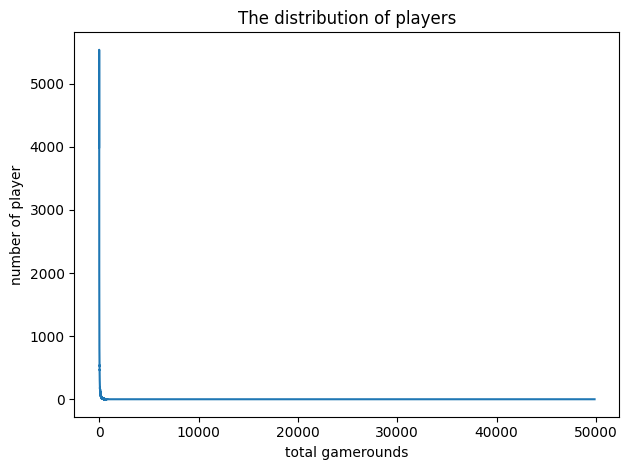

In [17]:
sns.lineplot(data=for_plot)
plt.title("The distribution of players")
plt.xlabel("total gamerounds")
plt.ylabel("number of player")
plt.tight_layout()
plt.show()

## Zoom-in: first 100 rounds

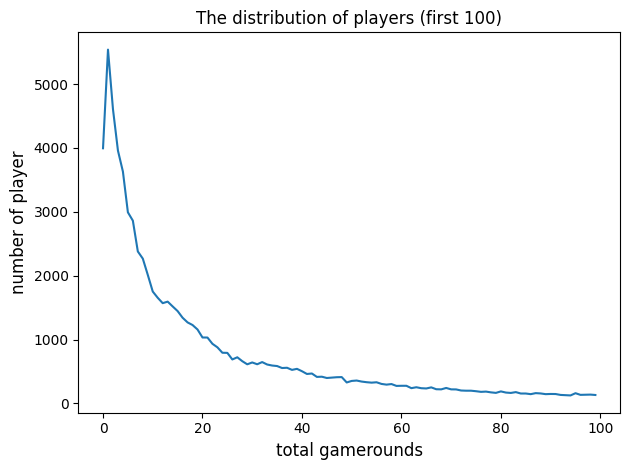

In [18]:
sns.lineplot(data=for_plot.head(100))
plt.title("The distribution of players (first 100)")
plt.xlabel("total gamerounds", size=12)
plt.ylabel("number of player", size=12)
plt.tight_layout()
plt.show()

In [19]:
never_played=df[df["sum_gamerounds"]== 0]["userid"].count()
print(f'Install but then never play: {never_played}')

Install but then never play: 3994


## Group-level visualization 

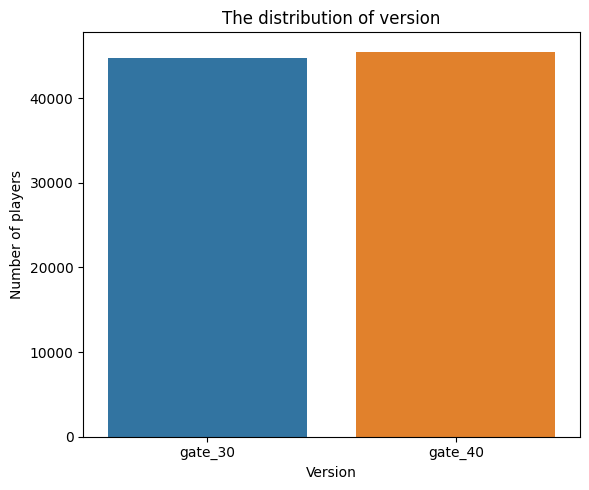

In [20]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x='version',hue='version')
plt.title('The distribution of version')
plt.xlabel("Version")
plt.ylabel("Number of players")
plt.tight_layout()
plt.show()

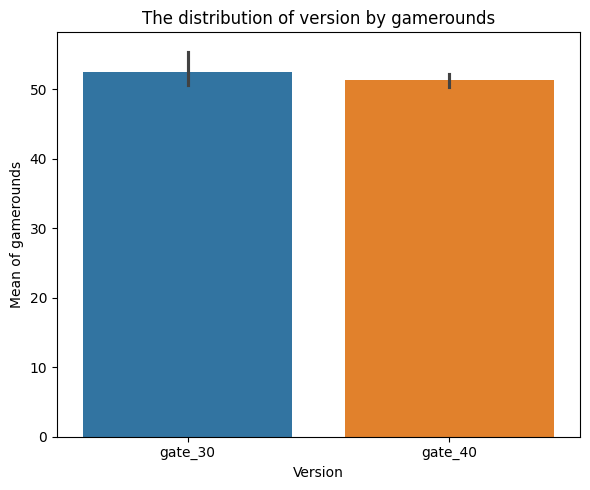

In [21]:
plt.figure(figsize=(6,5))
sns.barplot(data=df,x='version',y='sum_gamerounds',hue='version')
plt.title('The distribution of version by gamerounds')
plt.xlabel("Version")
plt.ylabel("Mean of gamerounds")
plt.tight_layout()
plt.show()

## Outlier check on `sum_gamerounds`

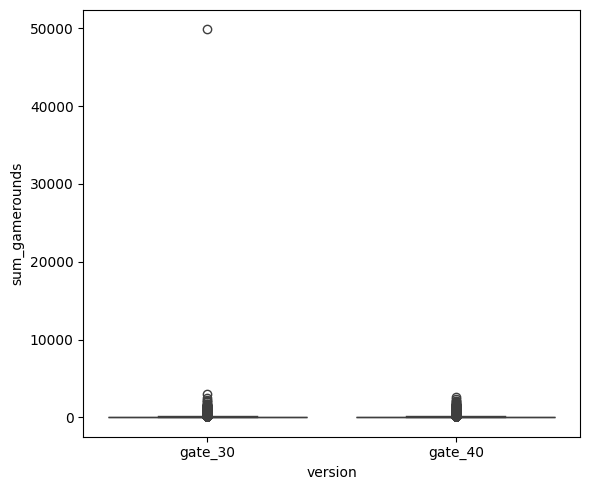

In [22]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df,x='version',y='sum_gamerounds',hue='version')
plt.tight_layout()
plt.show()

In [23]:
Q1=df['sum_gamerounds'].quantile(0.25)
Q3=df['sum_gamerounds'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
high_bound=Q3+1.5*IQR


In [24]:
print(f'IQR: {IQR}, lowerbound: {lower_bound}, highbound: {high_bound}')

IQR: 46.0, lowerbound: -64.0, highbound: 120.0


## Q99 vs Q999 as cutoff

In [25]:
Q99=df['sum_gamerounds'].quantile(0.99)

In [26]:
Q999=df['sum_gamerounds'].quantile(0.999).round(0)

In [27]:
df[df['sum_gamerounds']<0]

,userid,version,sum_gamerounds,retention_1,retention_7


In [28]:
counts = df.groupby('version')['userid'].count()
n = counts.sum()
expected = [n/2, n/2]
stat, p = chisquare(f_obs=counts.values, f_exp=expected)

print(f'Observed:  gate_30={counts["gate_30"]}, gate_40={counts["gate_40"]}')
print(f'Expected:  {expected[0]:.1f} / {expected[1]:.1f} (50/50)')
print(f'Chi2 stat: {stat:.4f}, p-value: {p:.4f}')
if p < 0.001:
    print('WARNING: SRM detected - randomization may be flawed.')
else:
    print('OK: no significant deviation from 50/50.')

Observed:  gate_30=44700, gate_40=45489
Expected:  45094.5 / 45094.5 (50/50)
Chi2 stat: 6.9024, p-value: 0.0086
OK: no significant deviation from 50/50.


## Save cleaned data 

In [29]:
df_clean=df[df['sum_gamerounds']<=Q999]

## Post-cleaning state

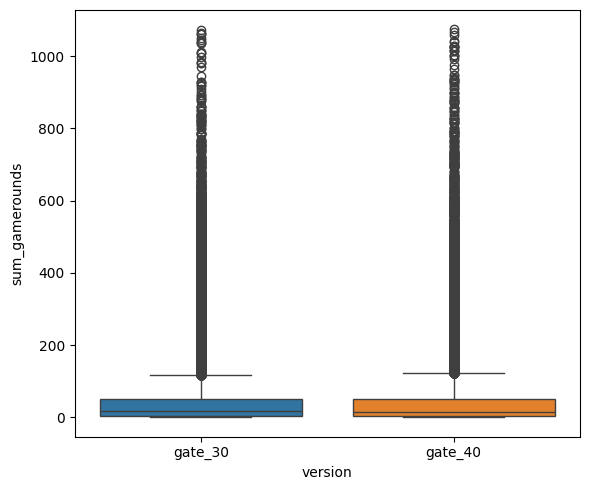

In [30]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df_clean,x='version',y='sum_gamerounds',hue='version')
plt.tight_layout()
plt.show()

In [31]:
df_clean.groupby('version')[['retention_1', 'retention_7']].agg(['count','median','mean','std']).T

version                  gate_30       gate_40
retention_1 count   44659.000000  45440.000000
            median      0.000000      0.000000
            mean        0.447704      0.441725
            std         0.497263      0.496598
retention_7 count   44659.000000  45440.000000
            median      0.000000      0.000000
            mean        0.189458      0.181140
            std         0.391876      0.385138

In [32]:
df_clean.to_csv('data/clean_cookie_cats.csv',index=False)